In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, TensorDataset
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tqdm.auto as tqdm
import pandas as pd
import random
from sklearn.metrics import f1_score
from pathlib import Path

# from models.dnn import DNN
# from models.cnn import CNN
# from models.resnet import ResNet

In [2]:
!nvidia-smi

Sun Oct 12 04:01:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
curr_time = time.strftime("%Y%m%d")

In [5]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [6]:
batch_size = 10000
T = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=T)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=T)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
test_size = len(test_dataset)

train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train set size: {len(train_dataset)}')
print(f'Validation set size: {len(val_dataset)}')
print(f'Test set size: {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.43MB/s]

Train set size: 48000
Validation set size: 12000
Test set size: 10000


The code below is trying speed up the training process by converting all the data into tensors and saving them as .pt files on a disk. Later these tensor are loaded directly from that disk instead of loading and applying transformations for every batch during training (which causes slow training).

Using this actually saves training time from 3mins -> 10s for DNN

In [7]:
def save_data(dataloader, X_path, y_path):
    inputs, targets = [], []
    for i, (X, y) in enumerate(dataloader):
        inputs.append(X)
        targets.append(y)
    inputs = torch.cat(inputs, dim=0)
    targets = torch.cat(targets, dim=0)
    torch.save(inputs, X_path)
    torch.save(targets, y_path)

SAVE_PATH = Path('./data/processed')
SAVE_PATH.mkdir(parents=True, exist_ok=True)
save_data(train_loader, SAVE_PATH / 'X_train.pt', SAVE_PATH / 'y_train.pt')
save_data(val_loader, SAVE_PATH / 'X_val.pt', SAVE_PATH / 'y_val.pt')
save_data(test_loader, SAVE_PATH / 'X_test.pt', SAVE_PATH / 'y_test.pt')

In [8]:
X_train = torch.load(SAVE_PATH / 'X_train.pt', map_location=device)
y_train = torch.load(SAVE_PATH / 'y_train.pt', map_location=device)
X_val = torch.load(SAVE_PATH / 'X_val.pt', map_location=device)
y_val = torch.load(SAVE_PATH / 'y_val.pt', map_location=device)
X_test = torch.load(SAVE_PATH / 'X_test.pt', map_location=device)
y_test = torch.load(SAVE_PATH / 'y_test.pt', map_location=device)

In [9]:
train_batch_size = 128
test_batch_size = 1000
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=test_batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=test_batch_size, shuffle=False)

# Define Model (this section is for colab)

In [10]:
class DNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        hidden_layers: list = [256, 128],
        output_dim: int = 10,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        """
        Args:
            input_dim: number of input features (for MNIST, 28*28=784)
            hidden_layers: list of hidden layer sizes, e.g. [256, 128]
            output_dim: number of output features (for MNIST, 10 classes)
            dropout: dropout rate (0.0 means no dropout)
            batch_norm: whether to use batch normalization
            activation: activation function
        """
        super(DNN, self).__init__()
        self.activation = self._activation(activation)

        layers = []

        prev_dim = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(self.activation)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1) # Flatten input image
        return self.model(x)

    def _activation(self, act_str):
        if act_str == 'relu':
            return nn.ReLU()
        elif act_str == 'tanh':
            return nn.Tanh()
        elif act_str == 'sigmoid':
            return nn.Sigmoid()
        elif act_str == 'leaky_relu':
            return nn.LeakyReLU()
        elif act_str == 'softmax':
            return nn.Softmax(dim=1)
        elif act_str == 'gelu':
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation function: {act_str}")

class CNN(nn.Module):
    def __init__(
        self,
        input_dim: int = 28*28,
        input_channels: int = 1,
        conv_layers: list = [32, 64],
        fc_layers: list = [128],
        output_dim: int = 10,
        kernel_size: int = 3,
        stride: int = 1,
        padding: int = 1,
        dropout: float = 0.0,
        batch_norm: bool = True,
        activation: str = 'relu',
    ):
        """
        Args:
            input_dim: number of input features (for MNIST, 28*28=784)
            input_channels: number of input channels (for MNIST, 1 channel)
            conv_layers: list of convolutional layers
            fc_layers: list of fully connected layer sizes after feature extraction
            output_dim: number of output features (for MNIST, 10 classes)
            kernel_size: size of the convolutional kernel, e.g. 3x3
            stride: stride of the convolution
            padding: padding for the convolution
            dropout: dropout rate (0.0 means no dropout)
            batch_norm: whether to use batch normalization
            activation: activation function
        """
        super(CNN, self).__init__()
        self.activation = self._activation(activation)

        # Convolutional layers
        conv_blocks = []
        prev_channels = input_channels
        for out_channels in conv_layers:
            conv_blocks.append(nn.Conv2d(prev_channels, out_channels, kernel_size, stride, padding))
            if batch_norm:
                conv_blocks.append(nn.BatchNorm2d(out_channels))
            conv_blocks.append(self.activation)
            conv_blocks.append(nn.MaxPool2d(2, 2))
            if dropout > 0:
                conv_blocks.append(nn.Dropout2d(dropout))
            prev_channels = out_channels

        self.feature_extractor = nn.Sequential(*conv_blocks)

        # Compute the immediate output size after conv layers
        img_size = int(input_dim ** 0.5)
        with torch.no_grad():
            dummy_input = torch.zeros(1, input_channels, img_size, img_size)
            conv_output = self.feature_extractor(dummy_input)
            conv_output_size = conv_output.view(1, -1).size(1)

        # Fully connected layers
        fc_layers = [conv_output_size] + fc_layers + [output_dim]
        fc_blocks = []
        for i in range(len(fc_layers) - 2):
            fc_blocks.append(nn.Linear(fc_layers[i], fc_layers[i+1]))
            if batch_norm:
                fc_blocks.append(nn.BatchNorm1d(fc_layers[i+1]))
            fc_blocks.append(self.activation)
            if dropout > 0:
                fc_blocks.append(nn.Dropout(dropout))
        # Final output layer
        fc_blocks.append(nn.Linear(fc_layers[-2], fc_layers[-1]))

        self.fc = nn.Sequential(*fc_blocks)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.fc(x)
        return x

    def _activation(self, act_str):
        if act_str == 'relu':
            return nn.ReLU()
        elif act_str == 'tanh':
            return nn.Tanh()
        elif act_str == 'sigmoid':
            return nn.Sigmoid()
        elif act_str == 'leaky_relu':
            return nn.LeakyReLU()
        elif act_str == 'softmax':
            return nn.Softmax(dim=1)
        elif act_str == 'gelu':
            return nn.GELU()
        else:
            raise ValueError(f"Unsupported activation function: {act_str}")

class ResidualBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
    ):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        self.downsample = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                # Force the feature maps to have the same shape
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        self.conv_layers = nn.Sequential(
            self.conv1,
            self.bn1,
            self.relu,
            self.conv2,
            self.bn2
        )

    def forward(self, x):
        out = self.conv_layers(x)
        out += self.downsample(x)  # Residual connection
        out = self.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(
        self,
        input_channels: int = 1,
        n_blocks: list = [2, 2, 2, 2],
        output_dim: int = 10,
    ):
        """
        Args:
            input_channels: number of input channels (for MNIST, 1 channel)
            n_blocks: list with number of residual blocks in each layer
            output_dim: number of output features (for MNIST, 10 classes)
        """
        super(ResNet, self).__init__()

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Follow ResNet18 architecture
        self.layer1 = self._make_layer(64, 64, n_blocks[0])
        self.layer2 = self._make_layer(64, 128, n_blocks[1], stride=2)
        self.layer3 = self._make_layer(128, 256, n_blocks[2], stride=2)
        self.layer4 = self._make_layer(256, 512, n_blocks[3], stride=2)

        # Final layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(512, output_dim)


    def forward(self, x):
        # First conv layer
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        # Residual layers
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        # Final layers
        out = self.avgpool(out)
        out = self.flatten(out)
        out = self.fc(out)
        return out

    def _make_layer(
        self,
        in_channels: int,
        out_channels: int,
        n_blocks: int,
        stride: int = 1
    ):
        """
        Create a layer composed of several residual blocks.

        Args:
            in_channels: number of input channels
            out_channels: number of output channels
            n_blocks: number of residual blocks
            stride: stride for the first block
        """
        blocks = [ResidualBlock(in_channels, out_channels, stride)]
        for _ in range(1, n_blocks):
            blocks.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*blocks)


# Models Training

In [11]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        test_loader,
        lr=0.001,
        early_stopping=True,
        early_stopping_patience=3,
    ):
        self.device = device
        self.model = model.to(self.device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

        # Early stopping
        self.early_stopping = early_stopping
        if early_stopping:
            self.early_stopping_patience = early_stopping_patience
            self.best_val_loss = float('inf')
            self.epochs_no_improve = 0
            self.best_weights = None

        self.history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': [],
            'train_f1': [],
            'val_f1': [],
        }

    def train_one_epoch(self):
        self.model.train()
        running_loss, correct, total = [], 0, 0

        all_preds, all_gts = [], []
        for X_train, y_train in tqdm.tqdm(self.train_loader, desc="Training", leave=False):
            X_train, y_train = X_train.to(self.device), y_train.to(self.device)

            self.optimizer.zero_grad()
            outputs = self.model(X_train)
            loss = self.criterion(outputs, y_train)
            loss.backward()
            self.optimizer.step()

            running_loss.append(loss.item())

            _, preds = torch.max(outputs.data, 1)
            total += y_train.size(0)
            correct += (preds == y_train).sum().item()

            all_preds.extend(preds.detach().cpu().numpy())
            all_gts.extend(y_train.detach().cpu().numpy())
        epoch_loss = np.mean(running_loss)
        epoch_acc = correct / total * 100

        # Compute F1 macro since all classes are equally important
        epoch_f1 = f1_score(all_gts, all_preds, average='macro')

        return epoch_loss, epoch_acc, epoch_f1

    @torch.no_grad()
    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_gts = [], []
        with torch.no_grad():
            for X_val, y_val in tqdm.tqdm(self.val_loader, desc="Validation", leave=False):
                X_val, y_val = X_val.to(self.device), y_val.to(self.device)

                outputs = self.model(X_val)
                loss = self.criterion(outputs, y_val)

                running_loss += loss.item() * X_val.size(0)
                _, preds = torch.max(outputs, 1)
                total += y_val.size(0)
                correct += (preds == y_val).sum().item()

                all_preds.extend(preds.detach().cpu().numpy())
                all_gts.extend(y_val.detach().cpu().numpy())

        epoch_loss = running_loss / len(self.val_loader.dataset)
        epoch_acc = correct / total * 100
        epoch_f1 = f1_score(all_gts, all_preds, average='macro')

        return epoch_loss, epoch_acc, epoch_f1

    @torch.no_grad()
    def test(self):
        self.model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for X_test, y_test in tqdm.tqdm(self.test_loader, desc='Testing', leave=False):
                X_test, y_test = X_test.to(self.device), y_test.to(self.device)
                outputs = self.model(X_test)
                _, preds = torch.max(outputs, 1)
                correct += (preds == y_test).sum().item()
                total += y_test.size(0)

        return correct / total * 100

    def fit(self, epochs=10, verbose=True, saved_model_path=None):
        start_time = time.time()
        for epoch in range(epochs):
            train_loss, train_acc, train_f1 = self.train_one_epoch()
            val_loss, val_acc, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)

            if verbose and (epoch + 1) % (epochs // 10) == 0:
                print(f'EPOCH [{epoch+1}/{epochs}]'
                      f' Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%'
                      f' | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

            if self.early_stopping:
                if val_loss < self.best_val_loss: # Improvement
                    self.best_val_loss = val_loss
                    self.epochs_no_improve = 0
                    self.best_weights = self.model.state_dict()
                else:
                    self.epochs_no_improve += 1
                    if self.epochs_no_improve >= self.early_stopping_patience:
                        print("Early stopping at epoch", epoch+1)
                        if self.best_weights is not None:
                            self.model.load_state_dict(self.best_weights)
                        break
        # Load best weights after training
        if self.best_weights is not None:
            self.model.load_state_dict(self.best_weights)

        if saved_model_path:
            torch.save(self.model.state_dict(), saved_model_path)

        print(f'Training time: {time.time() - start_time:.2f}s')

        return self.history

In [12]:
learning_rates = [0.1, 0.01, 0.001]
input_dim = 28*28
input_channels = 1
output_dim = 10
epochs = 10
activation = 'relu'
dropout = 0.0
batch_norm = True

In [13]:
models = {
    'DNN': DNN(
        input_dim=input_dim,
        hidden_layers=[256, 128],
        output_dim=output_dim,
        dropout=dropout,
        batch_norm=batch_norm,
        activation=activation,
    ).to(device),
    'CNN': CNN(
        input_channels=input_channels,
        conv_layers=[16, 32],
        fc_layers=[256],
        output_dim=output_dim,
        dropout=dropout,
        batch_norm=batch_norm,
        activation=activation,
    ).to(device),
    'ResNet': ResNet(
        input_channels=input_channels,
        n_blocks=[2, 2, 2, 2],
        output_dim=output_dim,
    ).to(device),
}

### Test if models' implementations are correct

In [14]:
sample_inputs, sample_labels = next(iter(train_loader))

models['DNN'].eval()
models['CNN'].eval()
models['ResNet'].eval()
y1 = models['DNN'](sample_inputs.to(device))
y2 = models['CNN'](sample_inputs.to(device))
y3 = models['ResNet'](sample_inputs.to(device))

y1.shape, y2.shape, y3.shape

(torch.Size([128, 10]), torch.Size([128, 10]), torch.Size([128, 10]))

In [15]:
model_path = './weights/'
result_path = './results/'
os.makedirs(model_path, exist_ok=True)
os.makedirs(result_path, exist_ok=True)

histories = []
for lr in learning_rates:
    for model_name, model in models.items():
        print(f'\nTraining {model_name} with learning rate {lr}...')
        trainer = Trainer(model, train_loader, val_loader, test_loader, lr=lr)
        history = trainer.fit(epochs=epochs, saved_model_path=os.path.join(model_path, f'{model_name}_lr{lr}.pth'))
        test_acc = trainer.test()
        print(f'{model_name} Test Accuracy: {test_acc:.2f}%')

        df = pd.DataFrame(history)
        df['model'] = model_name
        df['lr'] = lr
        df['epoch'] = np.arange(1, len(df) + 1)
        histories.append(df)


Training DNN with learning rate 0.1...


Training:   0%|          | 0/375 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

EPOCH [1/10] Train Loss: 0.2843, Train Acc: 91.41% | Val Loss: 0.2085, Val Acc: 94.04%


Training:   0%|          | 0/375 [00:00<?, ?it/s]

...

Training:   0%|          | 0/375 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

EPOCH [7/10] Train Loss: 0.0022, Train Acc: 99.95% | Val Loss: 0.0320, Val Acc: 99.37%
Early stopping at epoch 7
Training time: 90.63s


Testing:   0%|          | 0/10 [00:00<?, ?it/s]

ResNet Test Accuracy: 99.42%


In [16]:
histories

[   train_loss  val_loss  train_acc    val_acc  train_f1    val_f1 model   lr  \
 0    0.284251  0.208496  91.408333  94.041667  0.913183  0.940006   DNN  0.1   
 1    0.158102  0.160520  95.377083  95.258333  0.953328  0.952069   DNN  0.1   
 2    0.127469  0.167317  96.287500  95.300000  0.962594  0.952475   DNN  0.1   
 3    0.111358  0.189307  96.672917  94.916667  0.966471  0.948814   DNN  0.1   
 4    0.107669  0.120107  96.858333  96.800000  0.968329  0.967707   DNN  0.1   
 5    0.089453  0.143610  97.385417  96.266667  0.973647  0.962207   DNN  0.1   
 6    0.092044  0.156571  97.335417  96.250000  0.973176  0.962139   DNN  0.1   
 7    0.077249  0.165595  97.708333  96.008333  0.976894  0.959903   DNN  0.1   
 
    epoch  
 0      1  
 1      2  
 2      3  
 3      4  
 4      5  
 5      6  
 6      7  
 7      8  ,
    train_loss  val_loss  train_acc    val_acc  train_f1    val_f1 model   lr  \
 0    0.184886  0.120506  94.881250  96.525000  0.948410  0.964762   CNN  0.1  

In [17]:
histories_df = pd.concat(histories, ignore_index=True)
histories_df.to_csv(os.path.join(result_path, 'histories.csv'), index=False)

## Inference

In [18]:
def inference(model, dataloader, n_images, n_cols=4):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images[:n_images].to(device), labels[:n_images].to(device)
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    n_rows = (n_images + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols * 3, n_rows * 3))
    for i in range(n_images):
        plt.subplot(n_rows, n_cols, i + 1)
        img = images[i].cpu().numpy().squeeze()
        plt.imshow(img, cmap='gray')
        plt.title(f'GT: {labels[i].item()}, Pred: {preds[i].item()}', fontsize=16)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Inference with DNN...


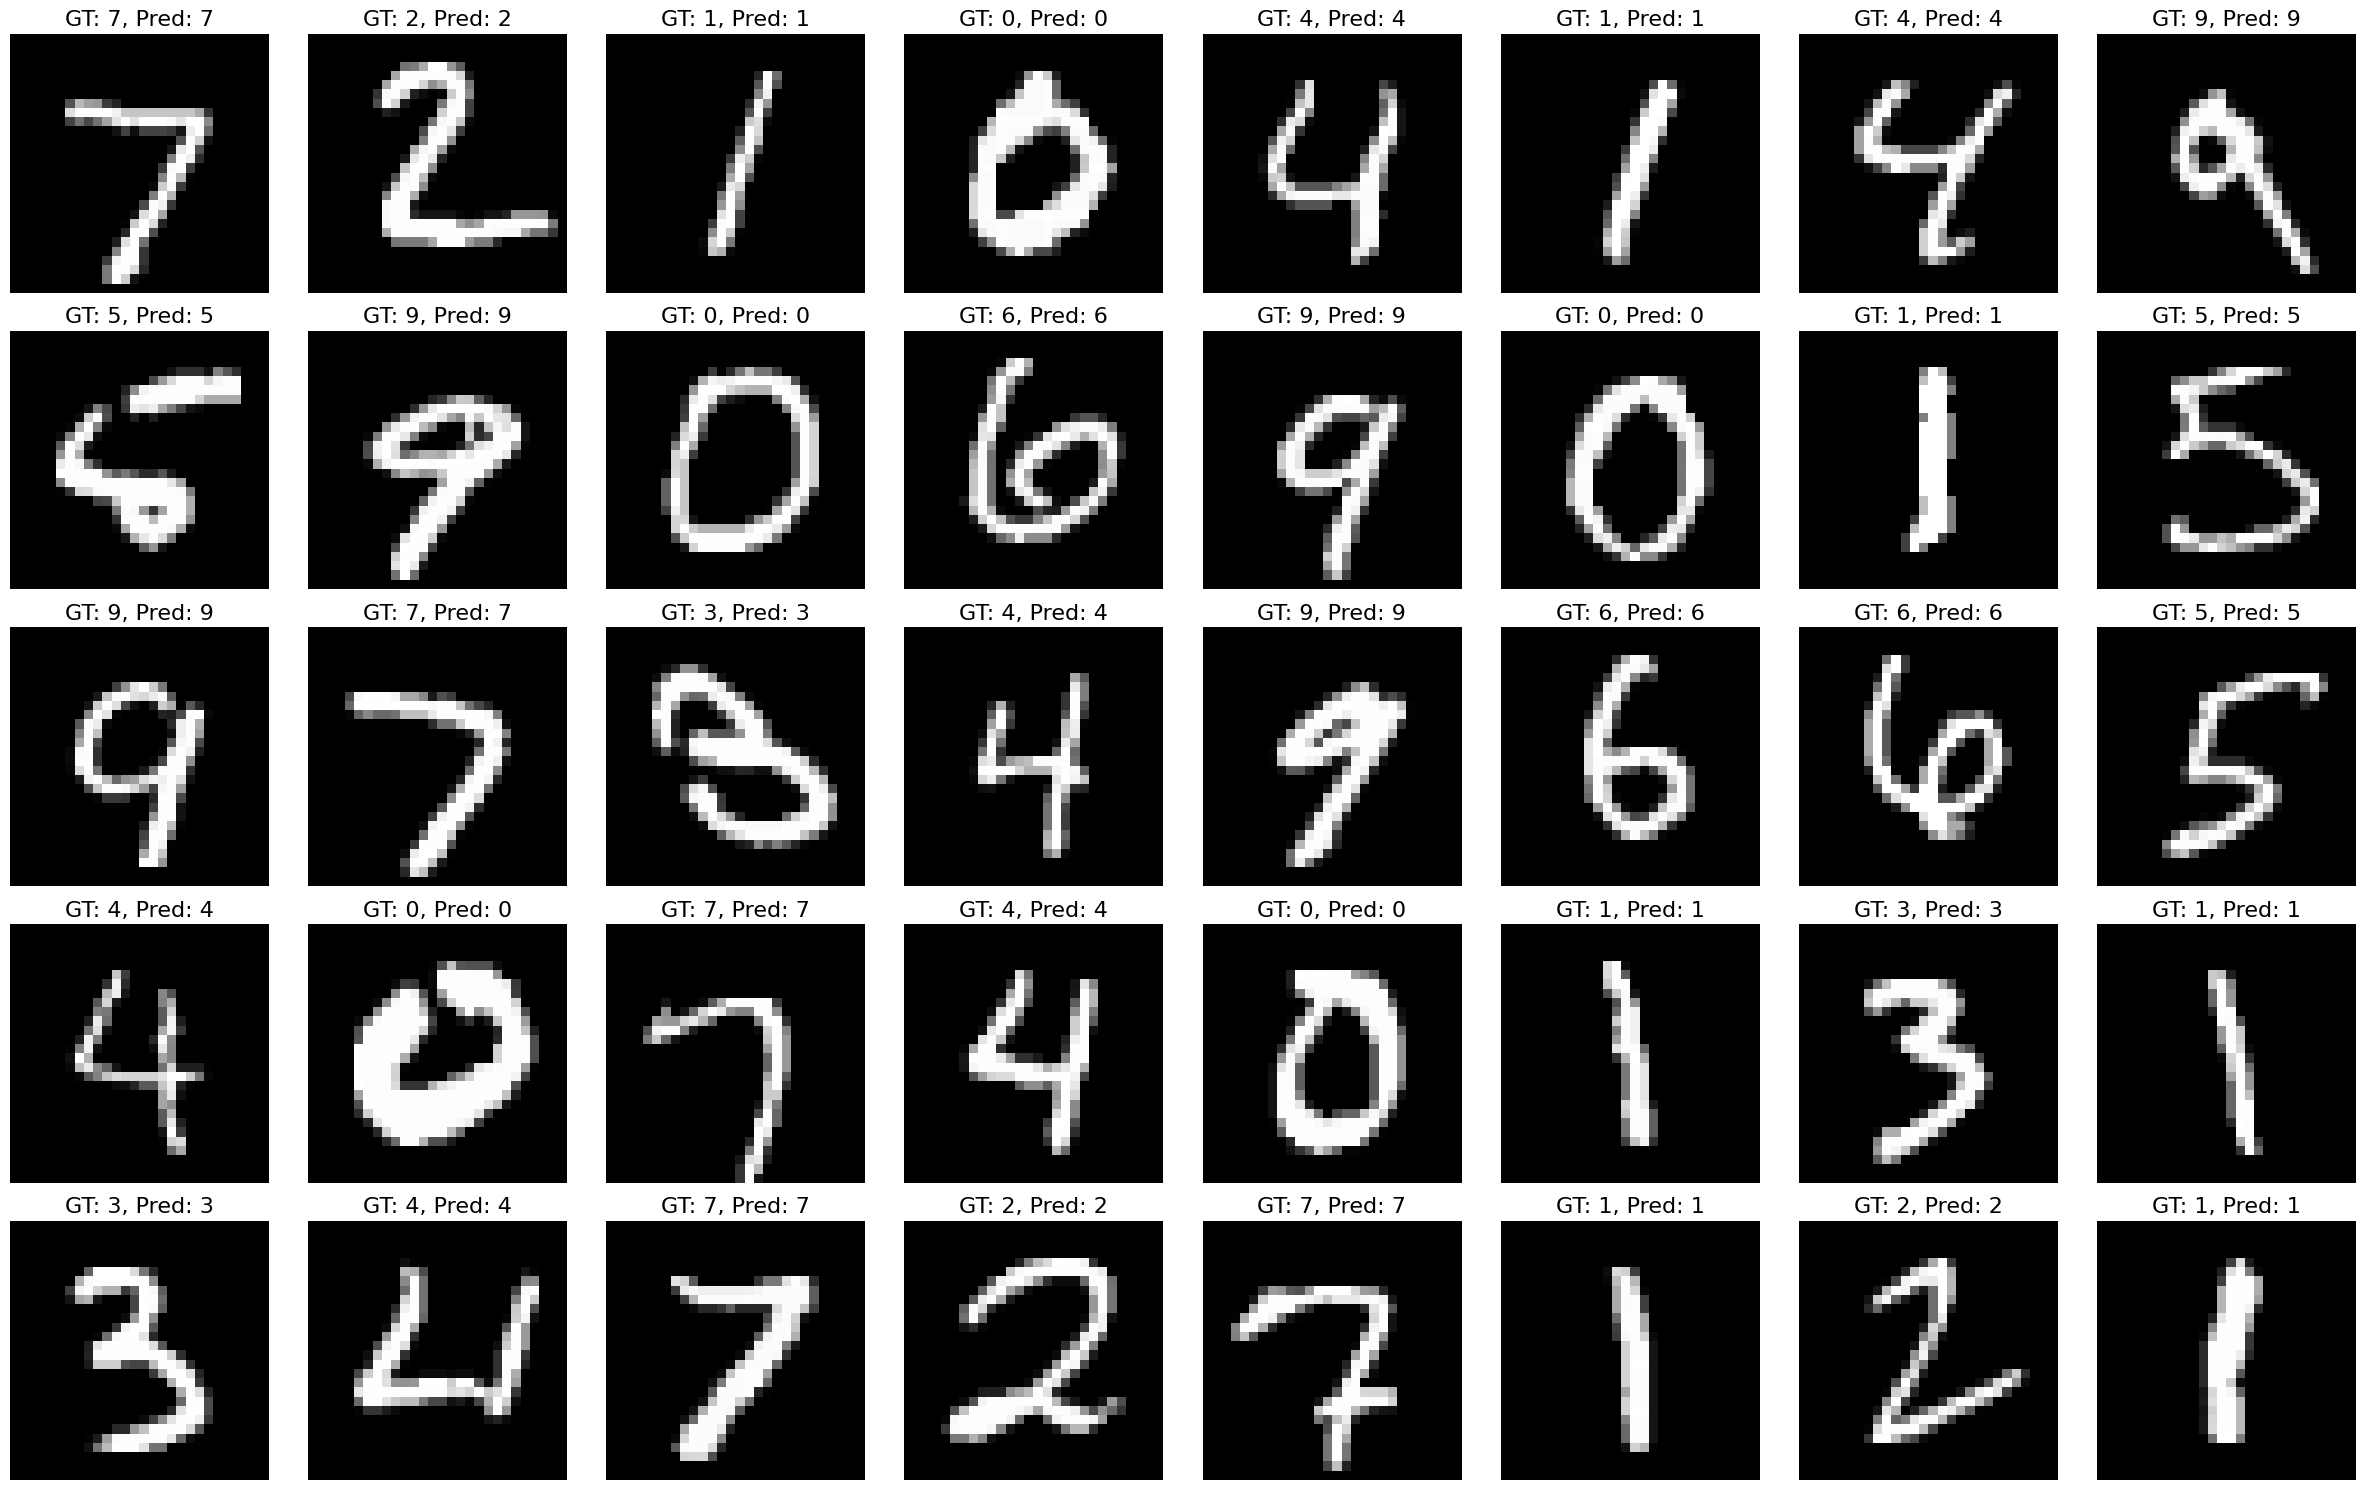


Inference with CNN...


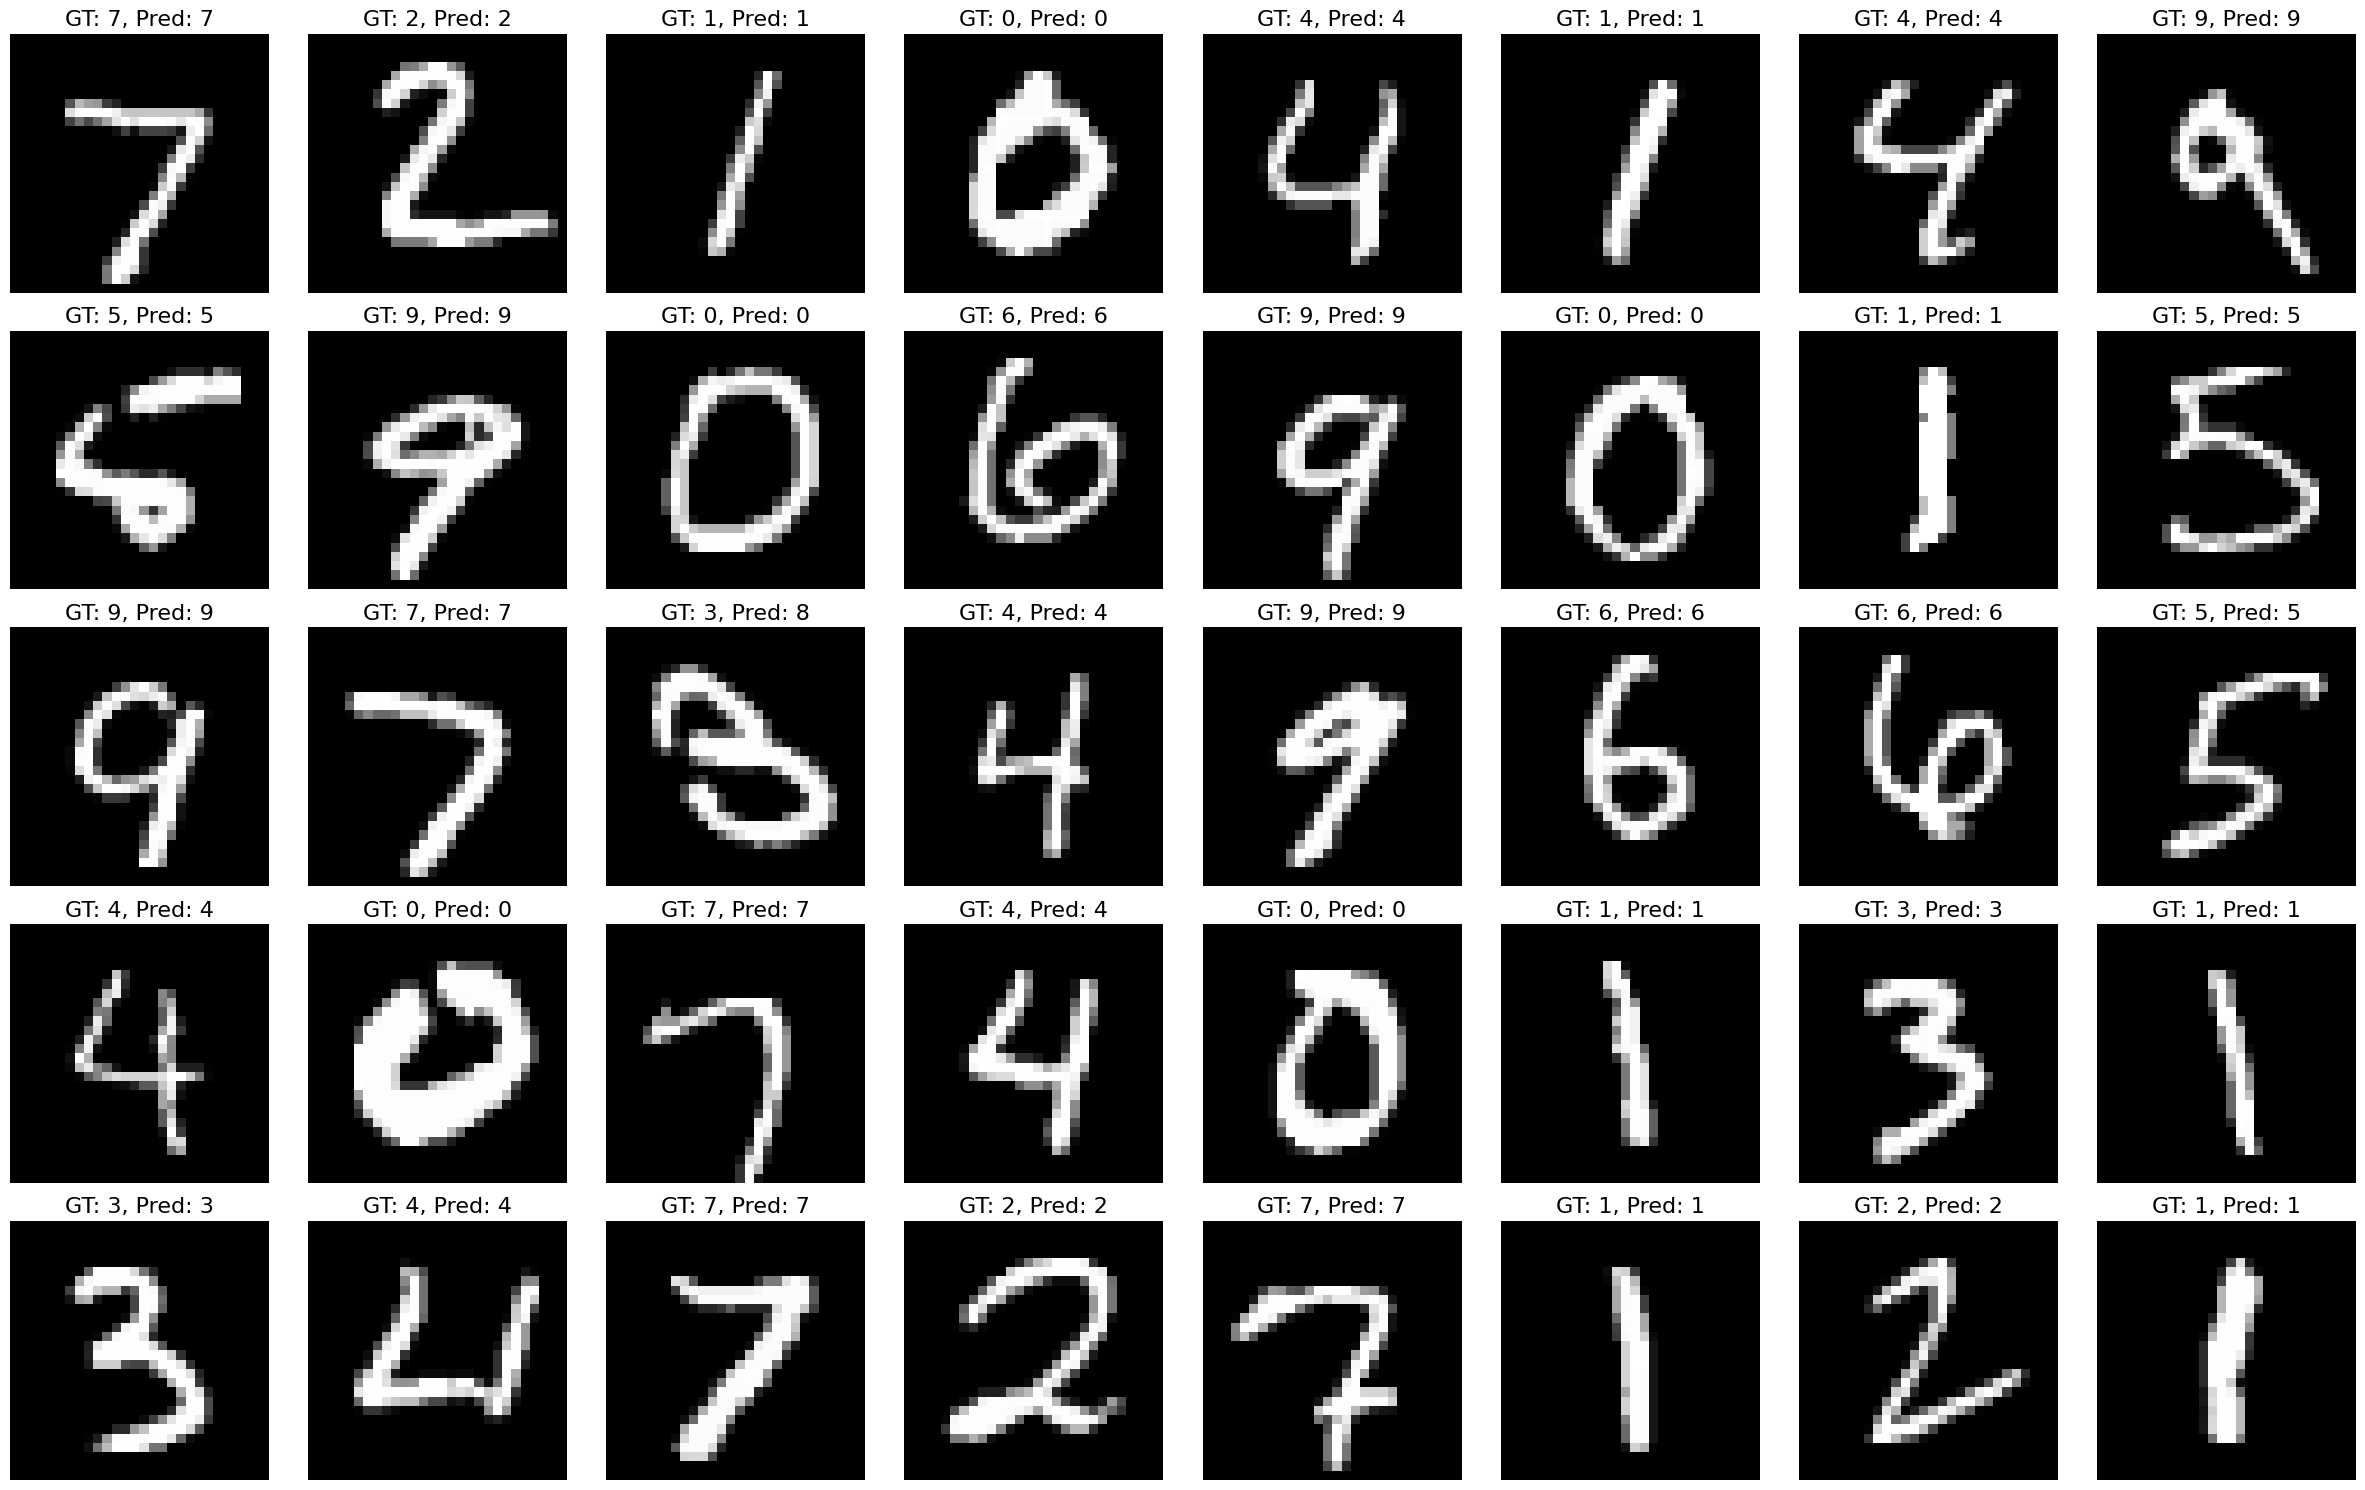


Inference with ResNet...


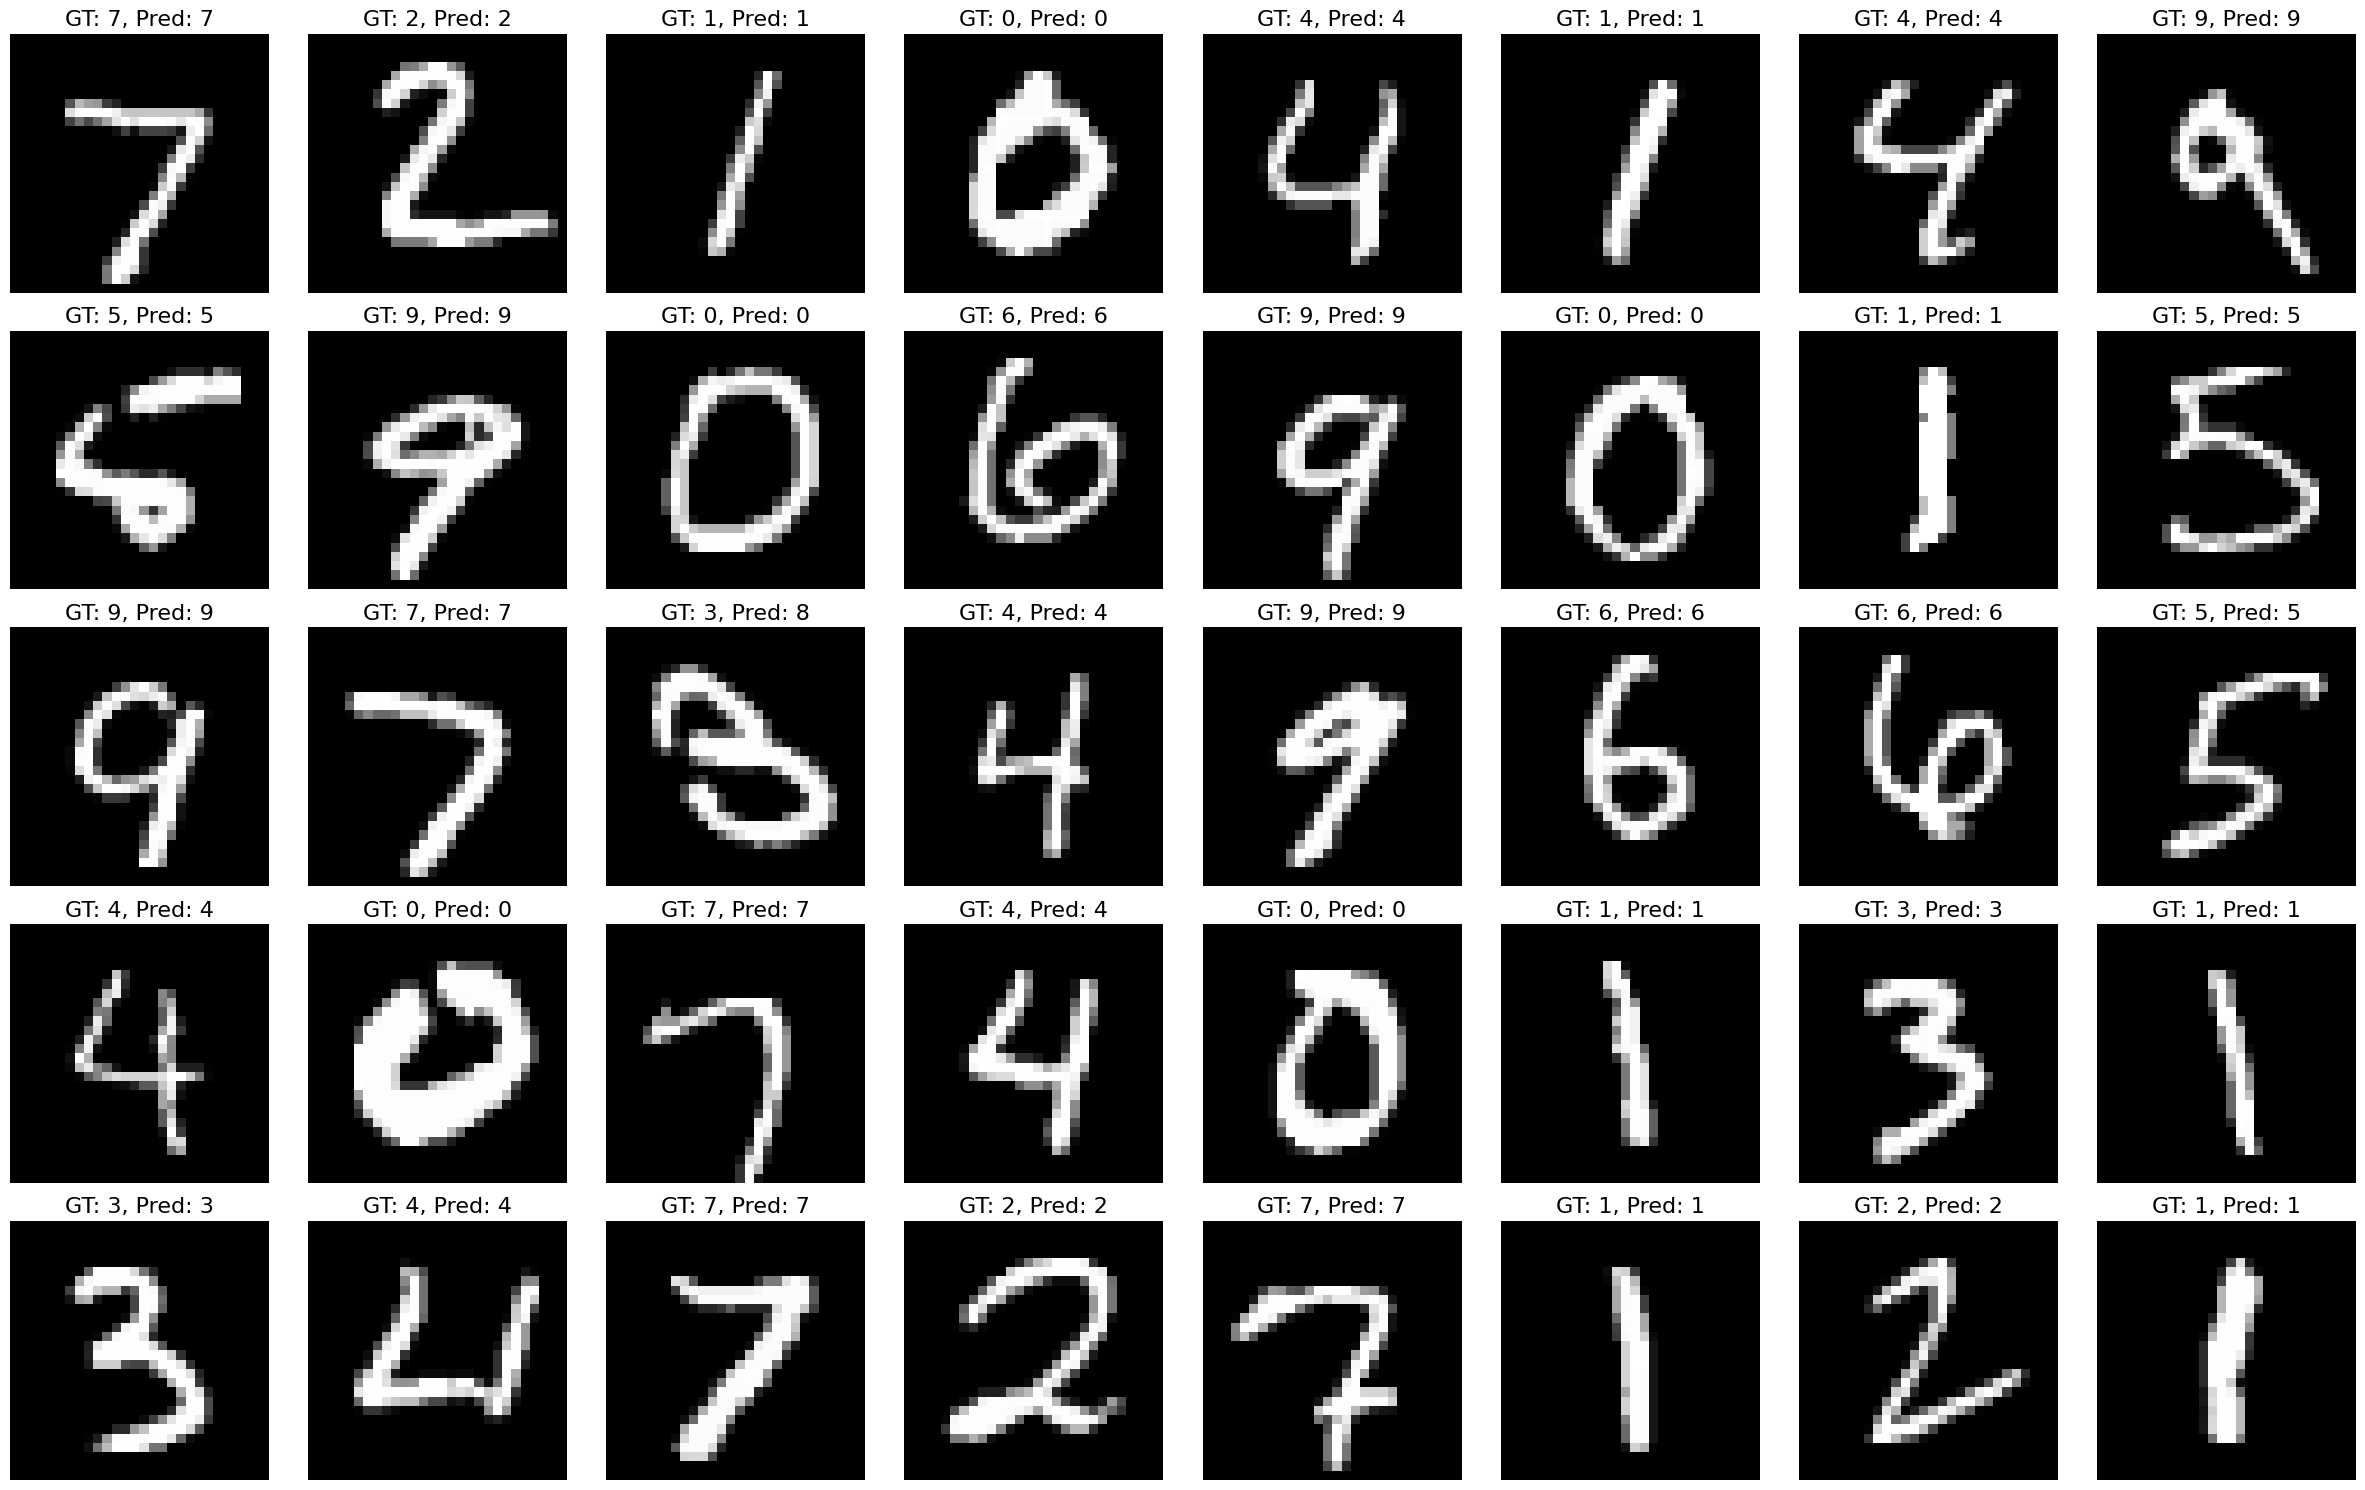

In [19]:
for model_name, model in models.items():
    print(f'\nInference with {model_name}...')
    model.load_state_dict(torch.load(os.path.join(model_path, f'{model_name}_lr0.01.pth')))
    inference(model, test_loader, n_images=40, n_cols=8)

## Download all model weights

In [25]:
from google.colab import files

!zip -r all_files.zip data/processed/ results/histories.csv weights/

  adding: data/processed/ (stored 0%)
  adding: data/processed/X_test.pt (deflated 91%)
  adding: data/processed/y_train.pt (deflated 91%)
  adding: data/processed/y_val.pt (deflated 90%)
  adding: data/processed/X_val.pt (deflated 91%)
  adding: data/processed/X_train.pt (deflated 91%)
  adding: data/processed/y_test.pt (deflated 90%)
  adding: results/histories.csv (deflated 58%)
  adding: weights/ (stored 0%)
  adding: weights/DNN_lr0.1.pth (deflated 7%)
  adding: weights/ResNet_lr0.001.pth (deflated 7%)
  adding: weights/CNN_lr0.001.pth (deflated 8%)
  adding: weights/DNN_lr0.01.pth (deflated 7%)
  adding: weights/CNN_lr0.1.pth (deflated 9%)
  adding: weights/CNN_lr0.01.pth (deflated 8%)
  adding: weights/ResNet_lr0.1.pth (deflated 7%)
  adding: weights/DNN_lr0.001.pth (deflated 7%)
  adding: weights/ResNet_lr0.01.pth (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
files.download('all_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>